# TTC Production Run — Exploratory Data Analysis of Reranker Minimization Threshold

First production batch from APHL (2026-06 eICRs). This notebook parses every
`TTCMetadataV2` record into one tidy table and explores whether we might be able to implement a reranker minimization threshold.


In [ ]:
pip install pandas matplotlib pyarrow seaborn numpy

In [1]:
# --- Config -------------------------------------------------------------
# Run locally against the downloaded archive (fast, free), or in Azure ML
# against the datastore (set USE_LOCAL=False on a compute instance).
USE_LOCAL = True

LOCAL_ROOT = "~/Downloads/ttc-output-0612-full"      # the unzipped archive
DATASTORE_PREFIX = "ttc-output-0612-full"            # folder we uploaded to workspaceblobstore
CACHE_PARQUET = "ttc_candidates.parquet"             # parsed cache (reload instantly)

import glob, json, os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

pd.set_option("display.max_colwidth", 60)


In [42]:
# --- Loader -------------------------------------------------------------
def _iter_metadata_files():
    """Yield (path_label, json_text) for every TTCMetadataV2 record."""
    if USE_LOCAL:
        root = os.path.join(os.path.expanduser(LOCAL_ROOT), "TTCMetadataV2")
        for fp in glob.glob(os.path.join(root, "**", "*.json"), recursive=True):
            with open(fp) as f:
                yield fp, f.read()
    else:
        # Azure ML: read straight from the workspaceblobstore datastore.
        from azure.identity import DefaultAzureCredential
        from azure.keyvault.secrets import SecretClient
        from azureml.fsspec import AzureMachineLearningFileSystem
        sc = SecretClient("https://dibbsttc6059789213.vault.azure.net/", DefaultAzureCredential())
        sub, rg, ws = (sc.get_secret(k).value for k in ("subscription", "resource-group", "workspace-name"))
        fs = AzureMachineLearningFileSystem(
            f"azureml://subscriptions/{sub}/resourcegroups/{rg}/workspaces/{ws}/datastores/workspaceblobstore"
        )
        for fp in fs.glob(f"{DATASTORE_PREFIX}/TTCMetadataV2/**/*.json"):
            with fs.open(fp) as f:
                yield fp, f.read().decode("utf-8")


def parse():
    """Parse all records into (eicr_df, cand_df).

    eicr_df: one row per eICR (for the passthrough funnel).
    cand_df: one row per candidate field in *processed* (non-passthrough) eICRs.
    """
    eicr_rows, rows = [], []
    for fp, text in _iter_metadata_files():
        doc = json.loads(text)
        parts = Path(fp).parts
        fdate = "-".join(parts[-4:-1]) if len(parts) >= 4 else None  # yyyy-mm-dd
        eicr_rows.append(dict(
            persistence_id=doc.get("persistence_id"), file_date=fdate,
            vendor=(doc.get("eicr_metadata") or {}).get("eicr_vendor"),
            passthrough=doc.get("passthrough"),
            passthrough_reason=doc.get("passthrough_reason"),
            n_issues=len(doc.get("ttc_schematron_issues") or []),
        ))
        if doc.get("passthrough"):
            continue  # passthrough = TTC took no action; its issues are all "no candidate found"
        for iss in (doc.get("ttc_schematron_issues") or []):
            cand = iss.get("candidate") or {}
            retriever_results = (((iss.get("opensearch_retrieved_scores") or {}).get("hits") or {}).get("hits")) or []
            reranker_results = iss.get("reranker_processed_results") or []
            new_translation = iss.get("new_translation")

            retriever_loincs = [(h.get("source") or {}).get("loinc_code") for h in retriever_results]
            retriever_decisions = [(h.get("source") or {}).get("description") for h in retriever_results]
            retriever_scores = [h.get("score") for h in retriever_results]
            n_retriever_results = len(retriever_results)

            top_retriever_loinc = retriever_loincs[0] if n_retriever_results else None
            top_retriever_text = retriever_decisions[0] if n_retriever_results else None
            top_retriever_score = retriever_scores[0] if n_retriever_results else None

            # bin the top scores into deciles
            top_retriever_score_decile = (top_retriever_score * 10) // 1 if top_retriever_score is not None else None

            top_retriever_gap_raw = (top_retriever_score - retriever_scores[1]) if n_retriever_results > 1 else None
            retriever_margins = [retriever_scores[i] - retriever_scores[i + 1] for i in range(len(retriever_scores) - 1)]

            # margin between the #1 hit and the next hit that is a *different* LOINC
            top_retriever_distinct_gap = next((top_retriever_score - s for L, s in zip(retriever_loincs[1:], retriever_scores[1:]) if L != top_retriever_loinc), None)
            

            matched = new_translation is not None
            final_loinc = new_translation.get("code") if matched else None
            reranker_top_decision = reranker_results[0]["code_string"] if reranker_results else None
            reranker_chosen_rank = (retriever_decisions.index(reranker_top_decision) + 1) if (reranker_top_decision in retriever_decisions) else None
            
            rows.append(dict(
                persistence_id=doc.get("persistence_id"), 
                file_date=fdate,
                vendor=(doc.get("eicr_metadata") or {}).get("eicr_vendor"),
                field_type=iss.get("field_type"), 
                candidate_text=cand.get("value"),
                outcome=("matched" if matched else (iss.get("unmatched_reason") or "unknown")),
                n_retriever_results=n_retriever_results, 
                n_distinct_retriever_loinc=len(set(retriever_loincs)) if n_retriever_results else 0,
                top_retriever_loinc=top_retriever_loinc, 
                top_retriever_score=top_retriever_score, 
                top_retriever_text=top_retriever_text,
                top_retriever_score_decile=top_retriever_score_decile,
                top_retriever_gap_raw=top_retriever_gap_raw, 
                top_retriever_distinct_gap=top_retriever_distinct_gap,
                matched=matched, 
                final_loinc=final_loinc,
                reranker_top_decision=reranker_top_decision, 
                reranker_top_score=(reranker_results[0]["score"] if reranker_results else None),
                reranker_chosen_rank=reranker_chosen_rank,
                agree_top1_desc=((reranker_top_decision == retriever_decisions[0]) if (reranker_top_decision and n_retriever_results) else None),
                agree_loinc=((final_loinc == top_retriever_loinc) if (matched and top_retriever_loinc) else None),
                retriever_loincs=retriever_loincs,
                retriever_decisions=retriever_decisions,
                retriever_scores=retriever_scores,
                retriever_margins=retriever_margins,
            ))
    return pd.DataFrame(eicr_rows), pd.DataFrame(rows)


# Parse once, then cache. Delete the parquet to force a re-parse.
if os.path.exists(CACHE_PARQUET):
    cand = pd.read_parquet(CACHE_PARQUET)
    eicr = pd.read_parquet(CACHE_PARQUET.replace(".parquet", "_eicr.parquet"))
    print("loaded from cache")
else:
    eicr, cand = parse()
    cand.to_parquet(CACHE_PARQUET, index=False)
    eicr.to_parquet(CACHE_PARQUET.replace(".parquet", "_eicr.parquet"), index=False)
    print("parsed and cached")

print("eICRs:", len(eicr), "| candidate rows (processed eICRs):", len(cand))
matched = cand[cand.matched].copy()
print("matched candidates:", len(matched))


parsed and cached
eICRs: 88 | candidate rows (processed eICRs): 49
matched candidates: 44


## Distribution Analysis

### What does the distribution of retriever margins look like?


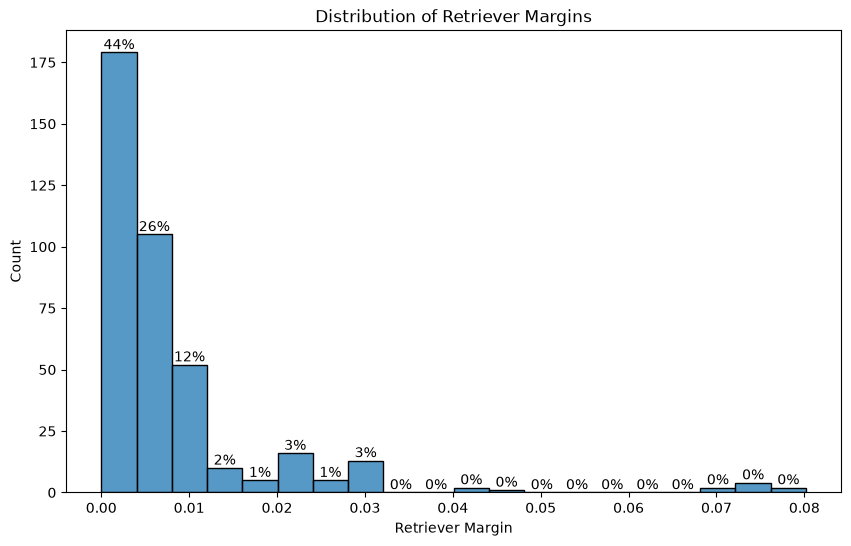

In [67]:
retriever_margins = cand[["retriever_margins"]].explode("retriever_margins").rename(columns={"retriever_margins": "retriever_margin"}).copy().reset_index(drop=True)
# Create a histogram of the retriever margins.
plt.figure(figsize=(10, 6))
sns.histplot(retriever_margins, x="retriever_margin", bins=20, kde=False)
plt.xlabel("Retriever Margin")
plt.ylabel("Count")
plt.title("Distribution of Retriever Margins")
# Add % to each bar
total = len(retriever_margins)
for p in plt.gca().patches:
    plt.gca().annotate(f'{int(p.get_height() / total * 100)}%', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom')
plt.show()

### What does the distribution of retriever margins look like between each rank position?

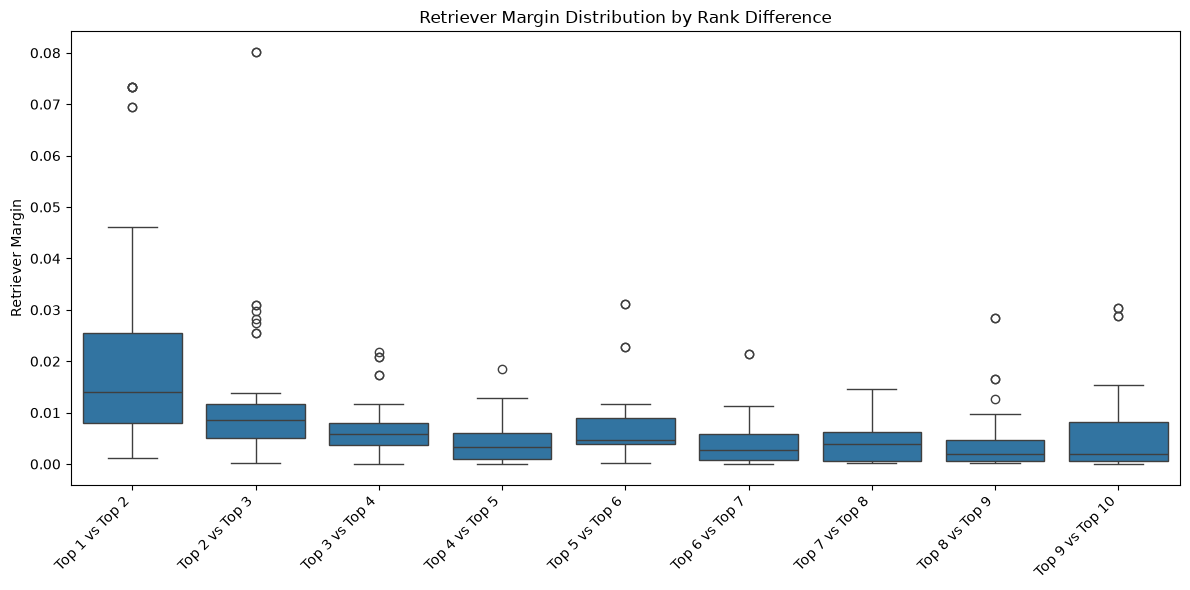

In [ ]:

retriever_margins_rank = cand[["retriever_margins"]].explode("retriever_margins").rename(columns={"retriever_margins": "retriever_margin"}).copy()
retriever_margins_rank["rank"] = retriever_margins_rank.groupby(level=0).cumcount() + 1


labels = {
    1: "Top 1 vs Top 2",
    2: "Top 2 vs Top 3",
    3: "Top 3 vs Top 4",
    4: "Top 4 vs Top 5",
    5: "Top 5 vs Top 6",
    6: "Top 6 vs Top 7",
    7: "Top 7 vs Top 8",
    8: "Top 8 vs Top 9",
    9: "Top 9 vs Top 10",}

retriever_margins_rank["rank_diff_label"] = (
    retriever_margins_rank["rank"]
    .map(labels)
    .fillna("Top 10+")
)

retriever_margins_rank = retriever_margins_rank.reset_index(drop=True)

plt.figure(figsize=(12, 6))
sns.boxplot(
    data=retriever_margins_rank,
    x="rank_diff_label",
    y="retriever_margin",
)

plt.xticks(rotation=45, ha="right")
plt.xlabel("")
plt.ylabel("Retriever Margin")
plt.title("Retriever Margin Distribution by Rank Difference")
plt.tight_layout()
plt.show()

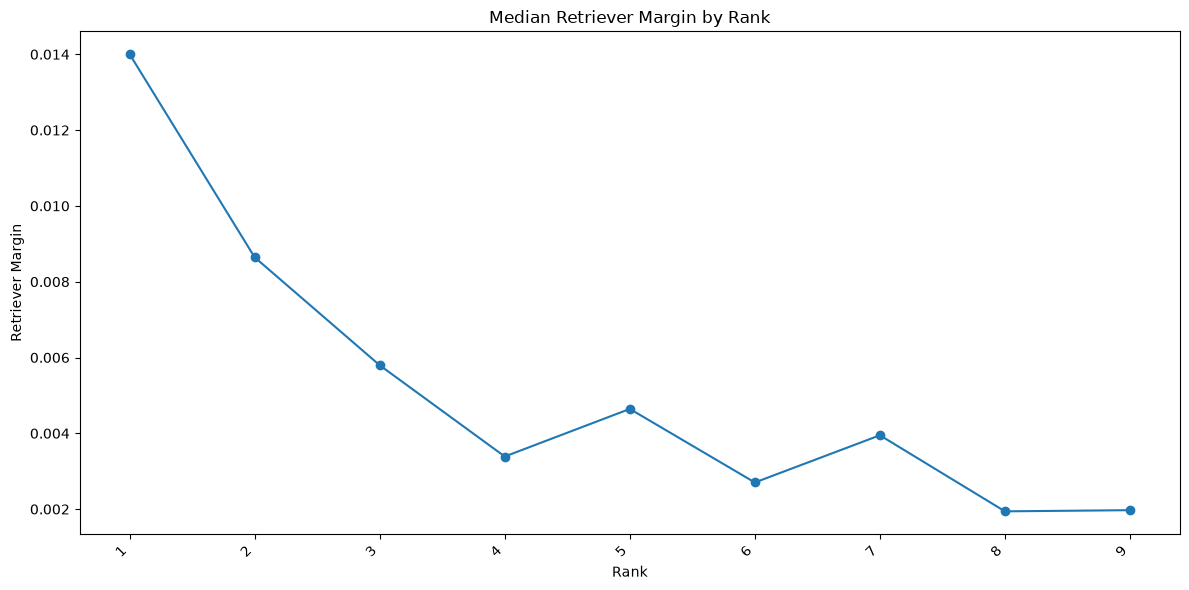

In [ ]:
plt.figure(figsize=(12, 6))
median_retriever_margins_rank =(
    retriever_margins_rank
    .groupby("rank")["retriever_margin"]
    .agg(
        median="median",
        q25=lambda x: np.percentile(x, 25),
        q75=lambda x: np.percentile(x, 75)
    )

)

plt.xticks(rotation=45, ha="right")
plt.xlabel("Rank")
plt.ylabel("Retriever Margin")
plt.title("Median Retriever Margin by Rank")
plt.tight_layout()
plt.show()

If there's a gap between 1-2-3 and then it flattens outm this suggests that the retrieve is usually very confident about the top result, but less confident about the ordering of the lower-ranked results. If there's a huge cliff between say ranks 1-3 and ranks 4-10, it might not be as useful to send rank 4-10 to the reranker.

### What does the distribution of top retriever cosine similarities look like in the training pipeline data?
This distribution will give us high level insight into what the cosine similarities look like when they are returned from the retriever (i.e., returned from Open Search but have not yet been reranked). 


Understanding this distribution is important when evaluating potential auto-rejection strategies. If the highest retrieval scores are tightly clustered within a narrow range (for example, most top scores are greater than 0.9), then an absolute cosine similarity threshold is unlikely to be an effective rejection criterion because it would provide little ability to distinguish between strong and weak retrieval results. In that scenario, even queries that ultimately produce poor results may still have high top retrieval scores. Conversely, if low-quality retrievals tend to have noticeably lower top cosine similarities than high-quality retrievals, the distribution may reveal candidate thresholds that could be used to automatically reject queries before reranking.

This analysis helps determine whether the top retriever score contains enough signal to support an auto-rejection threshold and, if so, where reasonable threshold candidates may exist.

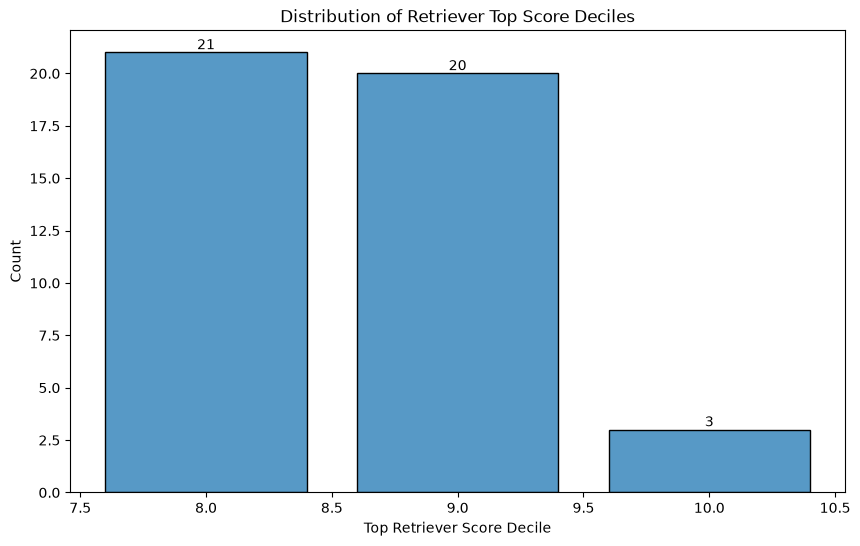

In [50]:
# Create a histogram of the top scores, binned into deciles. This is a good way to visualize the distribution of scores and see if there are any natural cutoffs for rejection.
plt.figure(figsize=(10, 6))
sns.histplot(cand, x="top_retriever_score_decile", bins=range(11), discrete=True, shrink=0.8)
plt.xlabel("Top Retriever Score Decile")
plt.ylabel("Count")
plt.title("Distribution of Retriever Top Score Deciles")
# Add count to each bar
for p in plt.gca().patches:
    plt.gca().annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom')
plt.show()


In [51]:
# Create table of the number of candidates per decile
decile_counts = cand.groupby("top_retriever_score_decile").size().reset_index(name="count")
print(decile_counts)

   top_retriever_score_decile  count
0                         8.0     21
1                         9.0     20
2                        10.0      3


### How much of the training pipeline traffic would be affected if we used [x] auto-rejection rule?
Here, we're measuring how frequently a proposed auto-rejection rule would trigger on the training pipeline data. This helps quantify the operational impact of the rule and provides context for any quality improvements or regressions observed later. We're answering the question "if we deployed this rule, what percentage of results would be automatically rejected?" Understanding this rejection rate helps us evaluate the tradeoff between reducing low-confidence results and preserving coverage for nonstandard text that would otherwise be standardized by TTC.

In [52]:
thresholds = np.arange(0.2, 1.0, 0.05)

for t in thresholds:
    pct_rejected = (cand["top_retriever_score"] < t).mean() * 100
    print(f"{t=}: {pct_rejected:.1f}% rejected")

results = pd.DataFrame({
    "threshold": np.arange(0.5, 1.0, 0.02)
})
results["pct_rejected"] = results["threshold"].apply(
    lambda t: (cand["top_retriever_score"] < t).mean() * 100
)
results


t=np.float64(0.2): 0.0% rejected
t=np.float64(0.25): 0.0% rejected
t=np.float64(0.3): 0.0% rejected
t=np.float64(0.35): 0.0% rejected
t=np.float64(0.39999999999999997): 0.0% rejected
t=np.float64(0.44999999999999996): 0.0% rejected
t=np.float64(0.49999999999999994): 0.0% rejected
t=np.float64(0.5499999999999999): 0.0% rejected
t=np.float64(0.5999999999999999): 0.0% rejected
t=np.float64(0.6499999999999999): 0.0% rejected
t=np.float64(0.7): 0.0% rejected
t=np.float64(0.7499999999999998): 0.0% rejected
t=np.float64(0.7999999999999998): 0.0% rejected
t=np.float64(0.8499999999999999): 14.3% rejected
t=np.float64(0.8999999999999999): 42.9% rejected
t=np.float64(0.9499999999999997): 79.6% rejected


,threshold,pct_rejected
0,0.50,0.000000
1,0.52,0.000000
2,0.54,0.000000
3,0.56,0.000000
4,0.58,0.000000
5,0.60,0.000000
6,0.62,0.000000
7,0.64,0.000000
8,0.66,0.000000
9,0.68,0.000000


## Manual Inspection
### What do the results look like for the ones that we keep and the ones that we throw away?
Are we auto-rejecting good results? Are we keeping bad ones?

In [54]:
# Highest scoring candidates where the retriever and reranker disagree on the top choice.
cand[["candidate_text","top_retriever_score","top_retriever_text","top_retriever_loinc","reranker_top_decision","reranker_top_score","final_loinc","reranker_chosen_rank"]].sort_values(by="top_retriever_score", ascending=False).head(20)

,candidate_text,top_retriever_score,top_retriever_text,top_retriever_loinc,reranker_top_decision,reranker_top_score,final_loinc,reranker_chosen_rank
6,pH,1.000000,pH,2753-2,pH Spec,0.887252,17433-4,6.0
33,designer benzodiazepines ur ql cfm,1.000000,Designer benzodiazepines Ur Ql Cfm,99262-8,Designer benzodiazepines Ur Ql,0.994603,107210-7,2.0
34,designer benzodiazepines ur ql cfm,1.000000,Designer benzodiazepines Ur Ql Cfm,99262-8,Designer benzodiazepines Ur Ql,0.994603,107210-7,2.0
14,synthetic cannabinoids ur ql cfm,0.995950,Cannabinoids synthetic Ur Ql Cfm,67126-3,Cannabinoids synthetic Ur Ql,0.994744,107208-1,2.0
13,synthetic cannabinoids ur ql cfm,0.995950,Cannabinoids synthetic Ur Ql Cfm,67126-3,Cannabinoids synthetic Ur Ql,0.994744,107208-1,2.0
18,hydrocodone ur CMP,0.940895,HYDROcodone Ur-mCnc,3681-4,HYDROcodone [Presence] in Urine,0.930281,12308-3,9.0
17,hydrocodone ur CMP,0.940895,HYDROcodone Ur-mCnc,3681-4,HYDROcodone [Presence] in Urine,0.930281,12308-3,9.0
39,oxycodone ur CMP,0.937363,oxyCODONE Ur-mCnc,11246-6,oxyCODONE [Presence] in Urine,0.951087,10998-3,10.0
38,oxycodone ur CMP,0.937363,oxyCODONE Ur-mCnc,11246-6,oxyCODONE [Presence] in Urine,0.951087,10998-3,10.0
16,gabapentin ur CMP,0.932627,Gabapentin Ur-mCnc,59680-9,Gabapentin:PrThr:Pt:Urine:Ord:,0.954551,68439-9,10.0


In [55]:
# Lowest scoring candidates where the retriever and reranker disagree on the top choice.
cand[["candidate_text","top_retriever_score","top_retriever_text","top_retriever_loinc","reranker_top_decision","reranker_top_score","final_loinc","reranker_chosen_rank"]].sort_values(by="top_retriever_score", ascending=True).head(20)

,candidate_text,top_retriever_score,top_retriever_text,top_retriever_loinc,reranker_top_decision,reranker_top_score,final_loinc,reranker_chosen_rank
23,nps not otherwise specified ur ql cfm,0.824384,Norpropoxyph Ur Ql Cfm,17376-5,PCP Ur Ql Cfm,0.910033,18392-1,2.0
24,nps not otherwise specified ur ql cfm,0.824384,Norpropoxyph Ur Ql Cfm,17376-5,PCP Ur Ql Cfm,0.910033,18392-1,2.0
32,dehydrotizanidine ur cfm-mcnc,0.832659,Deschloroetizolam Ur Cfm-mCnc,99266-9,traZODone Ur Cfm-mCnc,0.959701,92637-8,9.0
31,dehydrotizanidine ur cfm-mcnc,0.832659,Deschloroetizolam Ur Cfm-mCnc,99266-9,traZODone Ur Cfm-mCnc,0.959701,92637-8,9.0
47,dehydrotizanidine ur cfm-mcnc,0.832659,Deschloroetizolam Ur Cfm-mCnc,99266-9,traZODone Ur Cfm-mCnc,0.959701,92637-8,9.0
46,dehydrotizanidine ur cfm-mcnc,0.832659,Deschloroetizolam Ur Cfm-mCnc,99266-9,traZODone Ur Cfm-mCnc,0.959701,92637-8,9.0
7,leukocytes,0.848194,Leukocytes other/Leukocytes in Blood,26471-3,Leukocytes [Presence] in Urine,0.861945,33052-2,3.0
5,protein,0.871525,Protein [Mass/Vol],2885-2,Protein [Presence] in Urine,0.794344,2887-8,4.0
0,blood,0.873474,Volume of Blood,3157-5,Blood temp,0.814282,60834-9,4.0
26,designer opioids ur ql cfm,0.886991,Opiates Ur Ql Cfm,18390-5,Opiates Ur Ql Cfm,0.979572,18390-5,1.0


Initial look at the data above suggests that it may be difficult to implement an auto-rejection threshold because single word candidate texts like `blood` have very similar top retriever scores to candidate texts where TTC could find a plausible LOINC,e.g., `designer opioids ur ql cfm`.